# Update aFIB clustering

In [1]:
%load_ext autoreload

In [2]:
import numpy as np
import scanpy as sc

In [3]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/1c360b0b-eb2f-45a3-aba9-056026b39fa5.h5ad"
)

In [4]:
adata_raw = adata.raw.to_adata()
del adata.raw

In [5]:
adata

AnnData object with n_obs × n_vars = 225177 × 31332
    obs: 'orig.ident', 'nCount_RNA', 'SpecimenID', 'LibraryID', 'SampleID', 'Run', 'clusterNumber', 'subclass.l1', 'dataSource', 'diseasetype', 'Race', 'clusterClass', 'organism_ontology_term_id', 'assay_ontology_term_id', 'sampletype', 'disease_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'Age_binned', 'cell_type_ontology_term_id', 'author_cell_type', 'diabetes_history', 'hypertension', 'eGFR', 'is_primary_data', 'disease_category', 'nFeature_RNA', 'percent.mt', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'batch_condition', 'citation', 'default_embedding', 'schema_reference', '

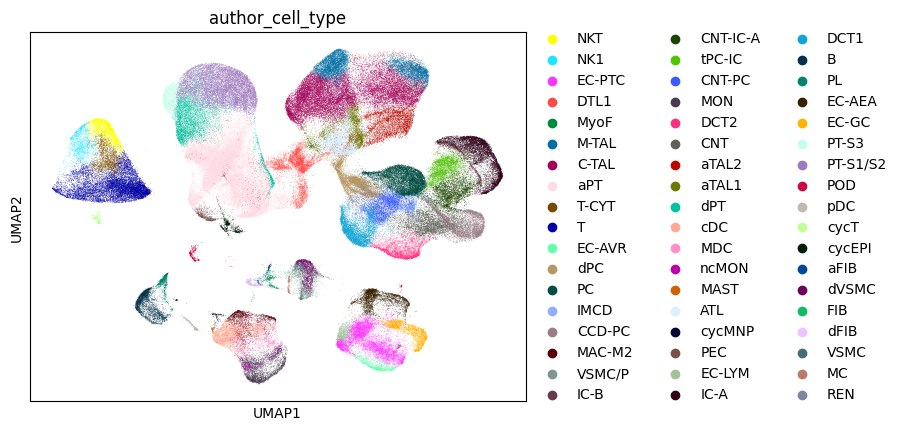

In [6]:
sc.pl.umap(adata, color=["author_cell_type"])

## Update aFIB clustering

In [12]:
clusters = ["aFIB"]

In [13]:
adata_subset = adata[
    adata.obs["author_cell_type"].isin(clusters)
]
adata_subset_raw = adata_raw[
    adata.obs["author_cell_type"].isin(clusters)
]

In [14]:
adata_subset

View of AnnData object with n_obs × n_vars = 276 × 31332
    obs: 'orig.ident', 'nCount_RNA', 'SpecimenID', 'LibraryID', 'SampleID', 'Run', 'clusterNumber', 'subclass.l1', 'dataSource', 'diseasetype', 'Race', 'clusterClass', 'organism_ontology_term_id', 'assay_ontology_term_id', 'sampletype', 'disease_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'Age_binned', 'cell_type_ontology_term_id', 'author_cell_type', 'diabetes_history', 'hypertension', 'eGFR', 'is_primary_data', 'disease_category', 'nFeature_RNA', 'percent.mt', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'batch_condition', 'citation', 'default_embedding', 'schema_referenc

In [19]:
adata_subset.var.index = adata_subset.var["feature_name"].astype(str)
adata_subset_raw.var.index = adata_subset_raw.var["feature_name"].astype(str)

In [20]:
sc.pp.pca(adata_subset)

In [21]:
sc.pp.neighbors(adata_subset)

In [22]:
sc.tl.umap(adata_subset)

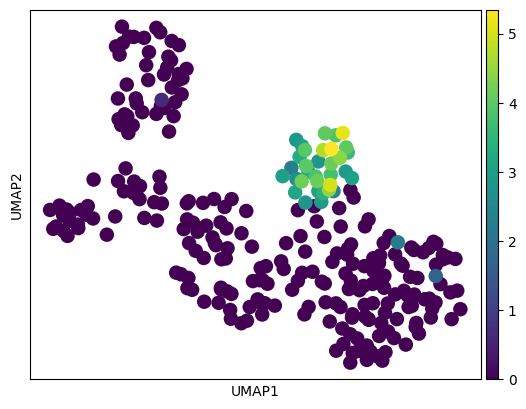

In [60]:
sc.pl.umap(
    adata_subset, 
    color=[
        "RGS5", # VSMC/P markers
    ],
    legend_loc="on data",
    save="_RGS5.png",
    title=""
)

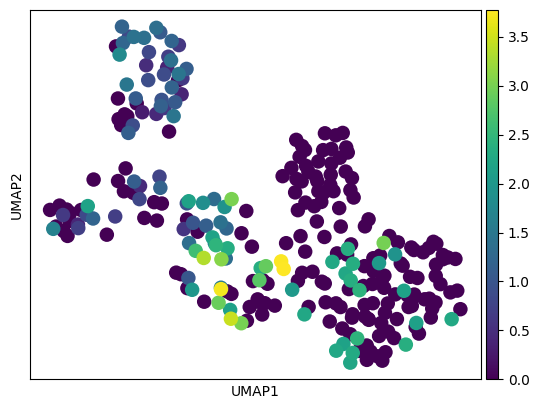

In [59]:
sc.pl.umap(
    adata_subset, 
    color=[
        "ABI3BP",  # aFIB markers
    ],
    legend_loc="on data",
    title="",
    save="_ABI3BP.png"
)

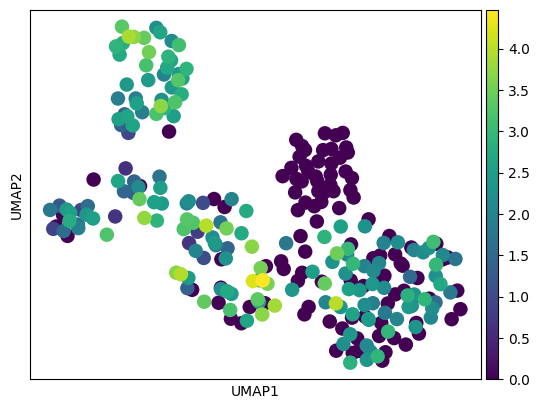

In [61]:
sc.pl.umap(
    adata_subset, 
    color=[
        "IGF1",  # aFIB markers
    ],
    legend_loc="on data",
    title="",
    save="_IGF1.png"
)

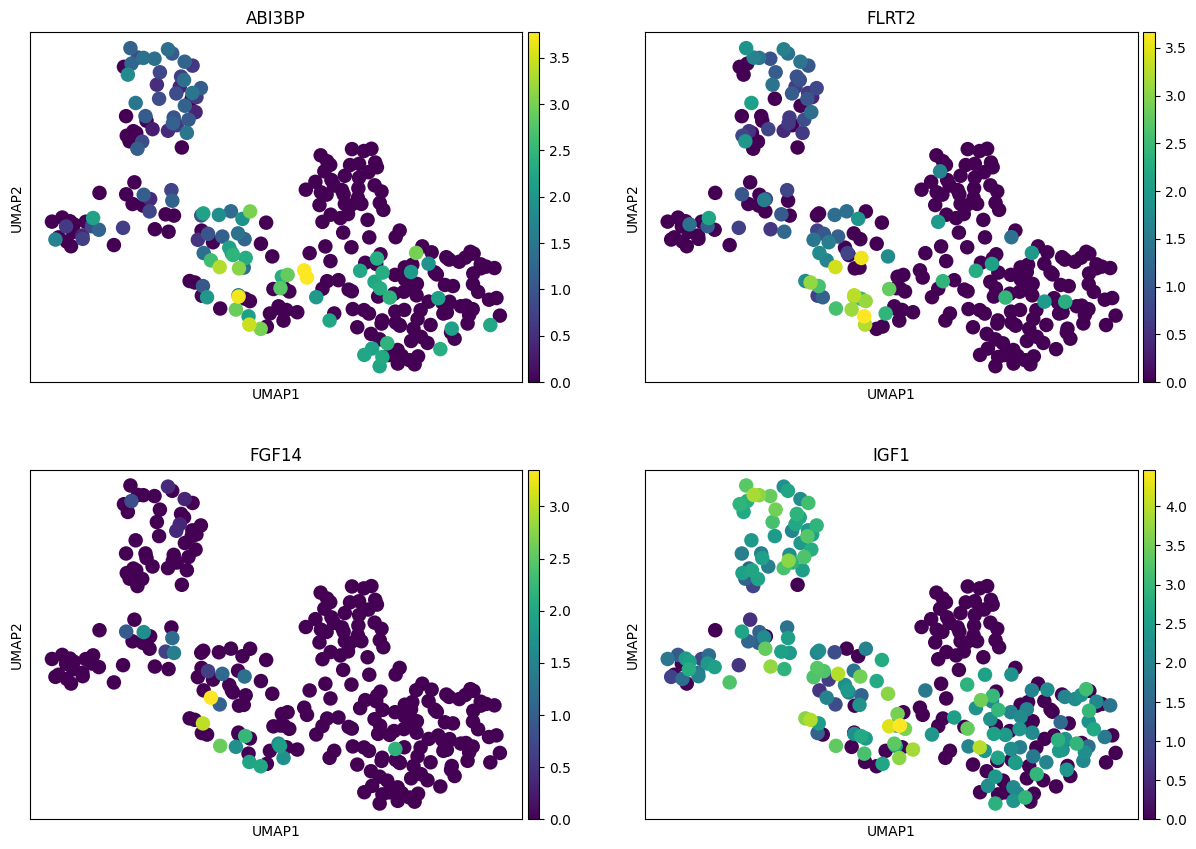

In [62]:
sc.pl.umap(
    adata_subset, 
    color=[
        "ABI3BP", "FLRT2", "FGF14", "IGF1"  # aFIB markers
    ],
    legend_loc="on data",
    ncols=2,
)

In [28]:
sc.tl.leiden(adata_subset, resolution=0.5)

In [29]:
adata_subset.obs.leiden.value_counts()

leiden
0    99
1    62
2    42
3    40
4    33
Name: count, dtype: int64

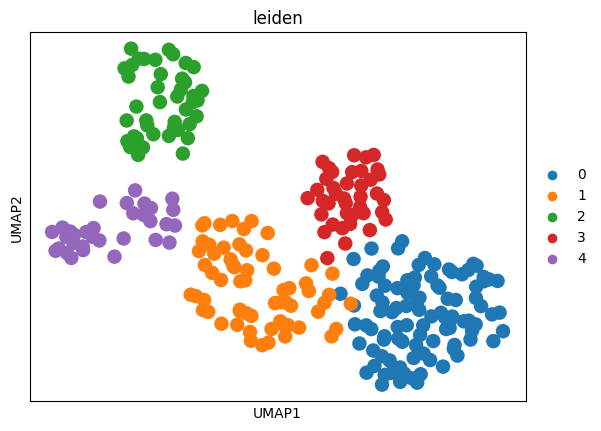

In [30]:
sc.pl.umap(adata_subset, color="leiden")

In [33]:
adata_subset.obs["leiden"] = adata_subset.obs["leiden"].replace({
    "0": "aFIB",
    "1": "aFIB",
    "2": "aFIB",
    "3": "VSMC/P",
    "4": "aFIB",
})

/tmp/ipykernel_894815/2005663686.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_subset.obs["leiden"] = adata_subset.obs["leiden"].replace({


In [34]:
assert adata_subset.var.index.equals(adata_subset_raw.var.index)
adata_subset_raw.obs["leiden"] = adata_subset.obs["leiden"]

/tmp/ipykernel_894815/851126727.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset_raw.obs["leiden"] = adata_subset.obs["leiden"]


In [35]:
%autoreload
from pairot.de_testing.testing import calc_pseudobulk_stats
from pairot.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [36]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_subset_raw,
    cluster_label="leiden",
    sample_label="SampleID"
)

R[write to console]: data.table 1.15.4 using 8 threads (see ?getDTthreads).  
R[write to console]: Latest news: r-datatable.com

Calculating AVA AUROC scores: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.59s/it]


In [37]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.0,
        aucroc_threshold=0.0
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.0,
        aucroc_threshold=0.0
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

In [38]:
from IPython.display import display

In [39]:
for cluster in np.unique(adata_subset_raw.obs.leiden):
    df = res[cluster]
    df = df.head(15)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

VSMC/P


,logFC,adj.P.Val,auroc,reference
ID,,,,
RGS5,4.91,0.000,0.91,['all']
RERGL,3.76,0.000,0.72,['all']
MUSTN1,3.54,0.001,0.68,['all']
LBH,2.45,0.042,0.63,['all']
MYH11,2.44,0.009,0.62,['all']
NRGN,2.29,0.006,0.60,['all']
PTP4A3,2.21,0.027,0.63,['all']
PTMA,1.16,0.001,0.64,['all']



aFIB


,logFC,adj.P.Val,auroc,reference
ID,,,,
PTGDS,4.62,0.015,0.77,['all']
SERPINF1,4.53,0.000,0.83,['all']
DCN,4.34,0.001,0.88,['all']
C1S,4.08,0.000,0.79,['all']
C1R,4.01,0.002,0.82,['all']
FBLN1,4.01,0.001,0.84,['all']
IGF1,3.96,0.006,0.86,['all']
EFEMP1,3.59,0.006,0.76,['all']
COL6A2,3.35,0.047,0.75,['all']


In [42]:
markers = [
    "RGS5",  # VSMC markers
    "ABI3BP", "FLRT2", "FGF14", "IGF1"  # aFIB markers
]


for cluster in np.unique(adata_subset_raw.obs.leiden):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


VSMC/P


,ID,logFC,adj.P.Val,auroc,reference
0,RGS5,4.91,0.000,0.91,['all']



aFIB


,ID,logFC,adj.P.Val,auroc,reference
6,IGF1,3.96,0.006,0.86,['all']


In [43]:
adata_subset.obs["author_cell_type_fine"] = adata_subset.obs["leiden"].astype("category").copy()

In [44]:
adata_subset.obs["author_cell_type_fine"] = adata_subset.obs["author_cell_type_fine"].astype("category")
adata_subset_raw.obs["author_cell_type_fine"] = adata_subset.obs["author_cell_type_fine"].astype("category")

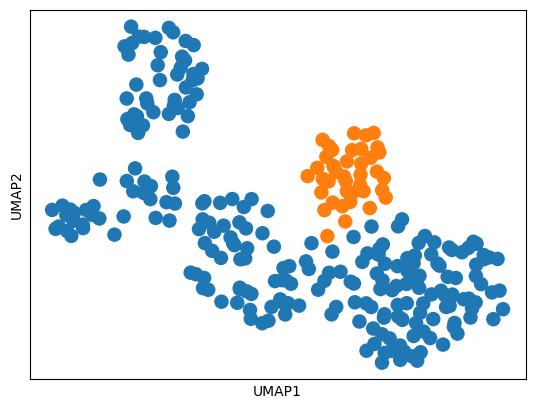

In [64]:
sc.pl.umap(adata_subset, color=["leiden"], title="", legend_loc=None, save="_VSMC_P_aFIB_after.png")

In [46]:
adata_subset.write_h5ad("aFIB_subset.h5ad")

## Update cell type annotations

In [51]:
import scanpy as sc

In [52]:
adata_subset = sc.read_h5ad("aFIB_subset.h5ad")

In [53]:
adata_preprocessed = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/preprocessed/"
    "0f528c8a-a25c-4840-8fa3-d156fa11086f.h5ad",
)

In [54]:
cells_to_update = adata_subset.obs[
    adata_subset.obs.author_cell_type_fine.isin(["VSMC/P", "aFIB"])
].index.to_numpy()

In [55]:
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype(str)
adata_preprocessed.obs.loc[cells_to_update, "cell_type_author"] = adata_subset.obs.loc[cells_to_update, "author_cell_type_fine"]
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype("category")

In [56]:
adata_preprocessed.obs.cell_type_author.value_counts()

cell_type_author
aPT         29397
C-TAL       21859
PT-S1/S2    13019
T           12338
PC           9376
M-TAL        8855
IC-A         7937
EC-PTC       7873
dPC          7217
dPT          6721
DCT1         5725
aTAL2        5552
ATL          5243
DTL1         5144
CNT-PC       5114
CCD-PC       5072
CNT-IC-A     4803
CNT          4780
PT-S3        3916
aTAL1        3842
cDC          3798
tPC-IC       3715
EC-AEA       3694
MON          3592
DCT2         3404
B            3261
NKT          3171
EC-GC        2827
MDC          2273
MAC-M2       2211
T-CYT        2185
VSMC/P       1978
NK1          1665
dVSMC        1646
IC-B         1305
EC-LYM       1254
EC-AVR       1245
PL           1051
cycEPI        964
dFIB          903
IMCD          847
PEC           775
ncMON         527
POD           462
cycT          421
pDC           376
MyoF          352
VSMC          317
MC            299
FIB           252
aFIB          236
cycMNP        191
MAST          148
REN            49
Name: count

In [57]:
adata_preprocessed.write_h5ad(
    "/vol/data/dataset-similarity/preprocessed/0f528c8a-a25c-4840-8fa3-d156fa11086f_aFIB.h5ad",
    compression="gzip"
)